<a href="https://colab.research.google.com/github/syedmahmoodiagents/genai_classes/blob/main/Stategraph_ReAct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install langchain_huggingface langgraph --q

In [2]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from typing import TypedDict
import re

from langchain_core.messages import HumanMessage

from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import InMemorySaver


In [3]:
import os
os.environ["HF_TOKEN"] = "hf_zIvXpRihcLDYQxQSByHOzDVeLxVhaQMEg"

In [4]:
llm = ChatHuggingFace(llm=HuggingFaceEndpoint(repo_id="openai/gpt-oss-20b"))

In [21]:
class NewState(TypedDict, total=False):
    question: str
    operation: str
    a: int
    b: int
    answer: int
    observation: str
    final_answer: str

In [22]:
def add_tool(a: int, b: int) -> int:
    """Add two numbers together."""
    return a + b


def multiply_tool(a: int, b: int) -> int:
    """Multiply two numbers together."""
    return a * b

In [38]:
# REACT AGENT
def react_agent(st: NewState):

    question = st["question"]
    previous_answer = st.get("answer")
    observation = st.get("observation")

    # Memory context
    if previous_answer is not None:
        memory_context = f"""Previous calculation result:{previous_answer}"""

    else:
        memory_context = """There is no previous calculation result."""



    # If we already have an observation, formulate final answer
    if observation is not None:
        response = llm.invoke(
            f"""
                You are a mathematical reasoning agent.

                The user asked: {question}

                Your tool produced this observation: {observation}

                Give the final answer to the user.

                Do not perform another calculation.

                Respond concisely.
            """
        )

        return {"final_answer": response.content}

    # --------------------------------------------------------
    # REASON + ACTION
    # --------------------------------------------------------

    response = llm.invoke(
        f"""
              You are a mathematical ReAct agent.

              {memory_context}

              Current user question:

              {question}

              Your job is to determine the next ACTION.

              Available actions:

              ADD
              MULTIPLY

              Rules:

              1. If the user refers to a previous result,
                use that previous result as the first number.

              2. Otherwise extract the two numbers
                from the current question.

              3. Determine whether the user wants ADD
                or MULTIPLY.

              Return ONLY:

              ADD
              or
              MULTIPLY
          """
    )


    op = response.content.strip().upper()

    num = re.findall(r"-?\d+", question)


    if previous_answer is not None:

        # if len(numbers) < 1:
        #     raise ValueError("Expected a number in the follow-up question.")

        x = previous_answer
        y = int(num[0])

    else:

        # if len(numbers) < 2:
        #     raise ValueError("Expected two numbers in the question.")

        x = int(num[0])
        y = int(num[1])


    return {"operation": op, "a": x, "b": y}

In [40]:
# ACTION / TOOL EXECUTOR
def execute_action(st: NewState):

    operation = st["operation"]
    a = st["a"]
    b = st["b"]

    # ACTION = ADD
    if operation == "ADD":
        result = add_tool(a, b)

    elif operation == "MULTIPLY":
        result = multiply_tool(a, b)

    # else:
    #     raise ValueError(f"Unknown action: {operation}")

    # Observation
    return {

        "answer": result,

        "observation": (
            f"Tool executed {operation}({a}, {b}) "
            f"and returned {result}."
        )
    }


def route_after_agent(st: NewState):

    # If the agent has already received
    # an observation, finish.
    if st.get("observation") is not None:
        return "finish"

    return "execute"


def final_node(st: NewState):
    return {"final_answer": st["observation"]}



In [41]:
builder = StateGraph(NewState)

builder.add_node("agent", react_agent)
builder.add_node("action", execute_action)
builder.add_node("final", final_node)

builder.set_entry_point("agent")
builder.add_conditional_edges("agent", route_after_agent, {"execute": "action", "finish": END})
builder.add_edge("action", "final")
builder.add_edge("final", END)

In [42]:
agent_pipe = builder.compile(checkpointer=InMemorySaver())

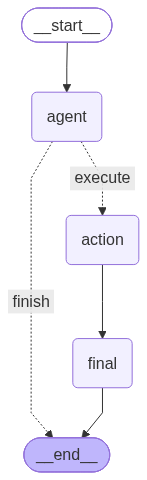

In [43]:
agent_pipe

In [44]:
cf = {'configurable': {'thread_id': 'user_1'}}

In [45]:
agent_pipe.invoke({"question": "What is 25 plus 15?"}, config=cf)


{'question': 'What is 25 plus 15?',
 'operation': 'ADD',
 'a': 25,
 'b': 15,
 'answer': 40,
 'observation': 'Tool executed ADD(25, 15) and returned 40.',
 'final_answer': 'Tool executed ADD(25, 15) and returned 40.'}

In [46]:
agent_pipe.invoke({"question": "Multiply the result by 10"}, config=cf)


{'question': 'Multiply the result by 10',
 'operation': 'ADD',
 'a': 25,
 'b': 15,
 'answer': 40,
 'observation': 'Tool executed ADD(25, 15) and returned 40.',
 'final_answer': '400'}